## Initial EDA on a Cleaned Validation File
This section loads a cleaned validation file and generates basic exploratory plots including ridership by hour, weekday, and top routes.  
Dataset: validation_report_buttecounty_2023-08_cleaned.csv

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load dataset
file_path = "C:/Users/zelaskar/Documents/B-Line_Project/data/processed/validation_report_buttecounty_2024-10_cleaned.csv"
df = pd.read_csv(file_path)

# Step 2: Parse timestamp
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['hour'] = df['timestamp'].dt.hour
    df['weekday'] = df['timestamp'].dt.day_name()
    df['date'] = df['timestamp'].dt.date

# Step 3: Basic summary
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.describe(include='all'))








Shape: (6096, 24)
Columns: ['id', 'timestamp', 'validation_id', 'user_id', 'pass_id', 'pass_agency_id', 'fare_id', 'rider_type', 'origin', 'fare_type', 'validator_id', 'vehicle_number', 'stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'trip_id', 'route_id', 'route_id.1', 'route_long_name', 'hour', 'weekday', 'date']
                                                 id  \
count                                          6096   
unique                                         6096   
top     CbQcmiltUZb4VAmXYyVSF9_gxm-2tSuaJ3QCPIC2Mjk   
freq                                              1   
mean                                            NaN   
min                                             NaN   
25%                                             NaN   
50%                                             NaN   
75%                                             NaN   
max                                             NaN   
std                                             NaN   

         

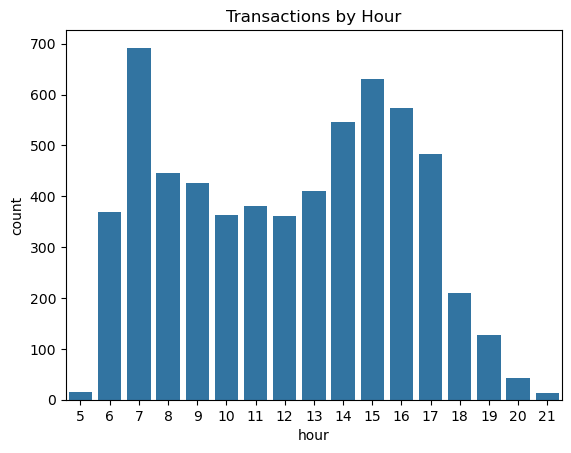

In [2]:
# Step 4: Transactions by Hour
if 'hour' in df.columns:
    sns.countplot(data=df, x='hour')
    plt.title("Transactions by Hour")
    plt.show()

📊 Transactions by Hour
This plot visualizes the number of transit validations by hour of the day. Clear spikes occur around 7 AM and 4–5 PM, indicating typical commuter rush hour periods. These trends suggest high rider concentration during start and end of work shifts.

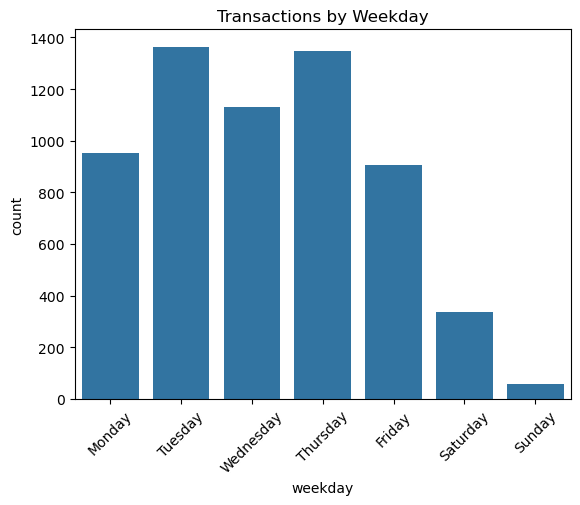

In [3]:
# Step 5: Transactions by Weekday
if 'weekday' in df.columns:
    sns.countplot(data=df, x='weekday', order=[
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
    plt.title("Transactions by Weekday")
    plt.xticks(rotation=45)
    plt.show()

📅 Transactions by Weekday
This chart displays ridership patterns across the week. Tuesday through Thursday see the highest activity, while weekends exhibit the lowest usage. The results indicate the system is primarily used for weekday commuting, likely by workers and students.



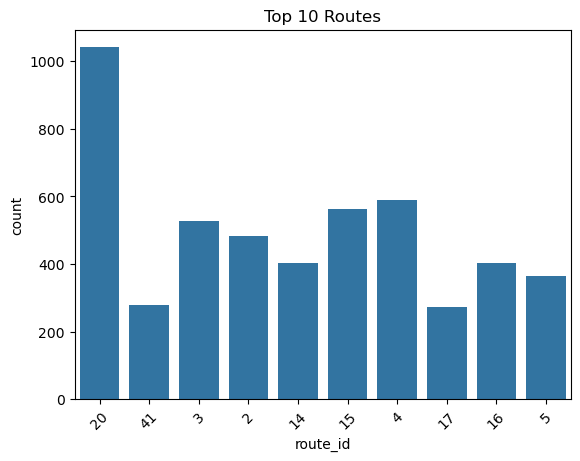

In [4]:
# Step 6: Top 10 Routes
if 'route_id' in df.columns:
    top_routes = df['route_id'].value_counts().index[:10]
    sns.countplot(data=df[df['route_id'].isin(top_routes)], x='route_id')
    plt.title("Top 10 Routes")
    plt.xticks(rotation=45)
    plt.show()

🚍 Top 10 Routes
The most frequently used routes are shown here, with Route 20 standing out as the highest in traffic. This route-level imbalance highlights opportunities for demand balancing, capacity adjustment, or deeper investigation into Route 20's importance.